Plot Data used for NN PDF retrievals

In [1]:
import sys,os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob
import cartopy.crs as ccrs

In [2]:
!ls /scr/tmp/mhayman/

aerosol_training_data.nc	      hippo_aerosol_training_data_valid.nc
afterpulse			      HRRR
CREDIT				      O2DIAL
hippo_aerosol_training_data.nc	      socrates_aerosol_training_data.nc
hippo_aerosol_training_data_test.nc   spiral
hippo_aerosol_training_data_train.nc  time_tag_data


In [3]:
file_lst = glob.glob(os.path.join("/scr/tmp/mhayman/","hippo_aerosol_training_data_*.nc"))

In [7]:
ds_lst = []
label_lst = []
for file in file_lst:
    print("Loading: "+file.split(os.sep)[-1])
    ds_lst.append(xr.open_dataset(file))
    if 'valid' in file.split(os.sep)[-1]:
        label_lst.append("Validation")
    elif 'test' in file.split(os.sep)[-1]:
        label_lst.append("Test")
    else:
        label_lst.append("Training")

Loading: hippo_aerosol_training_data_train.nc
Loading: hippo_aerosol_training_data_valid.nc
Loading: hippo_aerosol_training_data_test.nc


In [8]:
label_lst

['Training', 'Validation', 'Test']

In [7]:
ds_lst[0]['GGLAT']

<xarray.Dataset>
Dimensions:                  (wavelength: 3, data_index: 683577)
Coordinates:
  * wavelength               (wavelength) float64 1.064e-06 5.32e-07 3.55e-07
  * data_index               (data_index) int64 177282 177283 ... 1050743
Data variables: (12/14)
    backscatter_coefficient  (wavelength, data_index) float64 ...
    extinction_coefficient   (wavelength, data_index) float64 ...
    number_concentration     (data_index) float32 ...
    mean_r                   (data_index) float32 ...
    mean_r_2                 (data_index) float32 ...
    mean_r_3                 (data_index) float32 ...
    ...                       ...
    file_name                (data_index) object ...
    project_name             (data_index) object ...
    GGLAT                    (data_index) float32 ...
    GGLON                    (data_index) float32 ...
    GGALT                    (data_index) float32 ...
    Time                     (data_index) datetime64[ns] ...
Attributes:
    description:        UHSAS aerosol data products of mean radius and number...
    projects:           HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5
    lidar_wavelengths:  1064.00, 532.00, 355.00

In [9]:
color_lst = ['tab:blue','tab:green','tab:red']
# label_lst = ['Training','Validation','Test']

/opt/miniconda/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/opt/miniconda/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/opt/miniconda/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


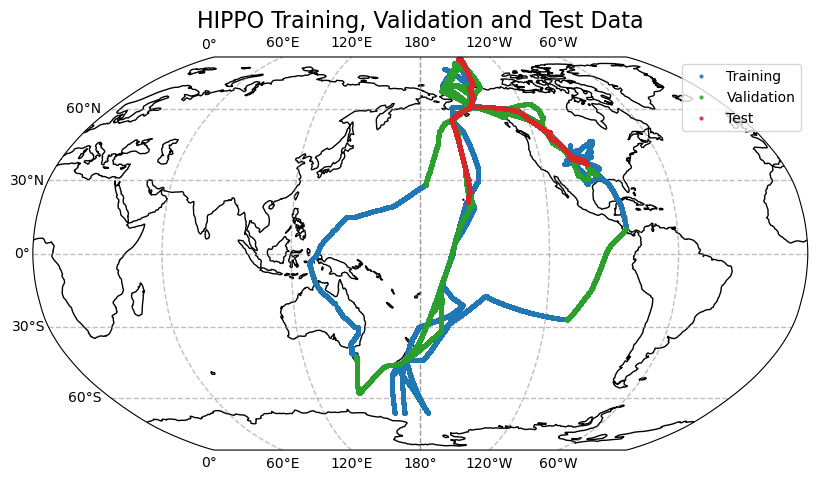

In [18]:
# --- 2. Create the plot ---
fig = plt.figure(figsize=(10, 8))
# Use the Robinson projection for a nice global view
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=180))

# --- 3. Add map features ---
# Set the global extent of the map
ax.set_global()
# Add the coastlines for geographical context
ax.coastlines()
# Add gridlines for latitude and longitude
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')

# --- 4. Plot the data ---
# Plot the first set of data in blue.
# The `transform=ccrs.PlateCarree()` is critical!
# It tells cartopy that our data (lon1, lat1) is in standard lat/lon coordinates
for ds_idx, ds in enumerate(ds_lst):
    ax.plot(ds['GGLON'].values, ds['GGLAT'].values, color=color_lst[ds_idx], linewidth=0, marker='o', alpha=0.8, markersize=2,
            transform=ccrs.PlateCarree(), label=label_lst[ds_idx])

# ax.plot(ds_lst[2]['GGLON'].values, ds_lst[2]['GGLAT'].values, color=color_lst[2], linewidth=0, marker='o',
#             transform=ccrs.PlateCarree(), label='Path %d'%ds_idx)


# # Plot the second set of data in red.
# ax.plot(lon2, lat2, color='red', linewidth=2, marker='x',
#         transform=ccrs.PlateCarree(), label='Path 2')

# --- 5. Finalize the plot ---
plt.title("HIPPO Training, Validation and Test Data", fontsize=16)
plt.legend()
plt.show()

In [ ]:
p_lst = []
for ds in ds_lst:
    p_lst.append(np.unique(ds['project_name'].values))

project_lst = np.unique(np.concatenate(p_lst))

/opt/miniconda/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/opt/miniconda/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/opt/miniconda/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/opt/miniconda/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/opt/miniconda/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/opt/

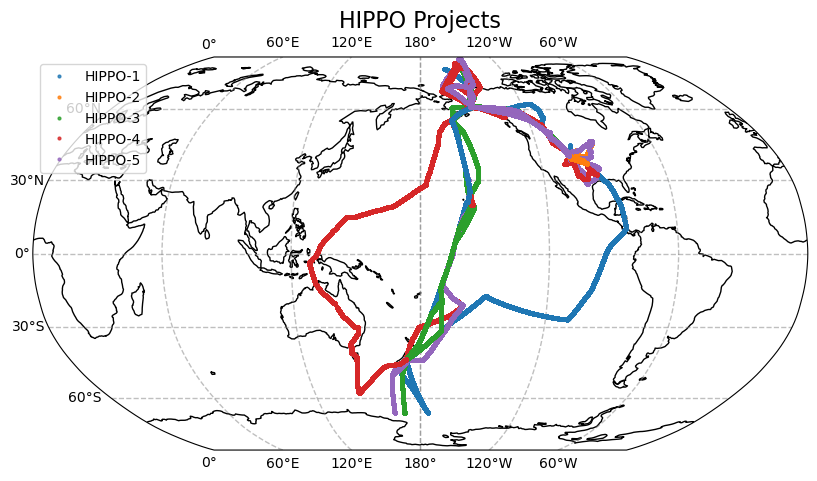

In [19]:
# --- 2. Create the plot ---
fig = plt.figure(figsize=(10, 8))
# Use the Robinson projection for a nice global view
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=180))

# --- 3. Add map features ---
# Set the global extent of the map
ax.set_global()
# Add the coastlines for geographical context
ax.coastlines()
# Add gridlines for latitude and longitude
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')

project_labeled = np.zeros(len(project_lst))

# --- 4. Plot the data ---
# Plot the first set of data in blue.
# The `transform=ccrs.PlateCarree()` is critical!
# It tells cartopy that our data (lon1, lat1) is in standard lat/lon coordinates
for ds_idx, ds in enumerate(ds_lst):
    for p_idx, project in enumerate(project_lst):
        plt_idx = np.where(ds['project_name'].values == project)
        plt_kwargs = {
            'color':'C%d'%p_idx,
            'linewidth':0, 
            'marker':'o', 
            'alpha':0.8, 
            'markersize':2,
            'transform':ccrs.PlateCarree()
        }
        if project_labeled[p_idx] == 0:
            plt_kwargs['label'] = project
            project_labeled[p_idx] = 1
        ax.plot(ds['GGLON'].values[plt_idx], ds['GGLAT'].values[plt_idx], **plt_kwargs)

# ax.plot(ds_lst[2]['GGLON'].values, ds_lst[2]['GGLAT'].values, color=color_lst[2], linewidth=0, marker='o',
#             transform=ccrs.PlateCarree(), label='Path %d'%ds_idx)


# # Plot the second set of data in red.
# ax.plot(lon2, lat2, color='red', linewidth=2, marker='x',
#         transform=ccrs.PlateCarree(), label='Path 2')

# --- 5. Finalize the plot ---
plt.title("HIPPO Projects", fontsize=16)
plt.legend()
plt.show()

(array([54539., 57454., 73154., 51704., 46989., 70851., 80995., 84260.,
        72982., 69063.]),
 array([-67.15809631, -51.93413925, -36.71018219, -21.48622322,
         -6.26226521,   8.96169281,  24.18564987,  39.40960693,
         54.63356781,  69.85752106,  85.08148193]),
 <BarContainer object of 10 artists>)

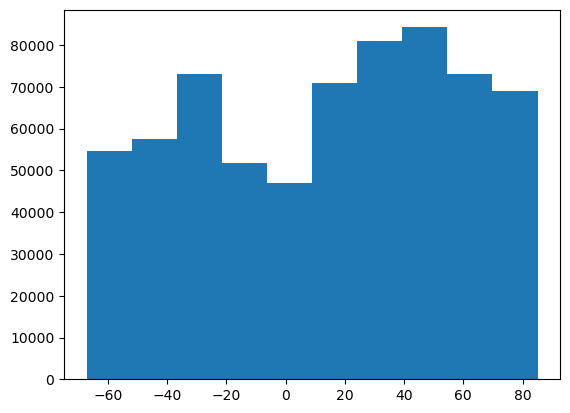

In [20]:
plt.figure()
plt.hist(ds_lst[0]['GGLAT'].values)

In [12]:
p_lst = []
for ds in ds_lst:
    p_lst.append(np.unique(ds['project_name'].values))

project_lst = np.unique(np.concatenate(p_lst))
    

In [13]:
project_lst


array(['HIPPO-1', 'HIPPO-2', 'HIPPO-3', 'HIPPO-4', 'HIPPO-5'],
      dtype=object)

In [6]:
for ds in ds_lst:
    ds.close()